# w207 Final Project - Data Preprocessing

Healthy vs. Bleached Coral Images Dataset

Workbook created by: Marisa Aubert

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow import keras
from keras import metrics

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

DATA_PATH = "/Users/marisadeluccia/Desktop/Desktop - Mac/MIDS/DATASCI207/Final Project/coral_images"

## Data Ingestion

In [64]:
# NOTE: This code cell only was written by Priyanka Bhatnagar. Copy/pasted from her
# notebook (coral_images_EDA.ipynb) to ensure consistent data ingestion

# Load the image dataset
def load_data(path_to_data):
    '''Load 2D images and their corresponding labels
    Parameters:
    path_to_data (str): This is the path to data
    Returns:
    images (np.ndarray): A numpy array of shape (N, 224, 224, 3)
    labels (np.ndarray): A numpy array of shape (N)
    '''
    ## load images and labels
    images = []
    labels = []

    label_names = sorted(os.listdir(path_to_data)) # label folders

    for label_name in label_names:
        label_folder = os.path.join(path_to_data, label_name)

        if not os.path.isdir(label_folder): # skip the non image folder.
            continue

        for file_name in os.listdir(label_folder): # loop through images in each folder
            file_path = os.path.join(label_folder, file_name)

            if not os.path.isfile(file_path): # skip non-image files just in case
                continue

            try:
                image = load_img(file_path, target_size=(224, 224)) # resize while loading image
                image_array = img_to_array(image) # convert image to np array
                images.append(image_array)
                labels.append(label_name)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")
    
    return np.array(images), np.array(labels) # return np arrays

images, labels = load_data(DATA_PATH)

## Data Preprocessing

### Label Encoding

In [65]:
encoder = LabelEncoder().fit(list(set(labels))) # fit on unique labels
encoded_labels = encoder.transform(labels) # apply to labels array (will get labels from 0 to 1)
encoded_labels_classes = list(encoder.classes_) # store mapping generated by the encoder

### Shuffling and Splitting Datasets

In [66]:
def split_data(images, labels, split):
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # Shuffles datasets
    shuffled_indices = np.random.permutation(len(images))
    X = images[shuffled_indices]
    Y = labels[shuffled_indices]
    
    # Creates indices for splits
    split_1, split_2, split_3 = int(len(images)*split[0]), int(len(images)*(split[0]+split[1])), int(len(images)*sum(split))

    # Creates split datasets
    X_train, X_val, X_test = X[:(split_1)], X[split_1:split_2], X[split_2: split_3]
    y_train, y_val, y_test = Y[:(split_1)], Y[split_1:split_2], Y[split_2: split_3]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [67]:
# Defining train, val, and test data splits (60%/20%/20%)
split = (0.6, 0.2, 0.2)

# Creating train, val, and test data sets
X_train, y_train, X_val, y_val, X_test, y_test = split_data(images, encoded_labels, split)

# Printing shapes of each dataset
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)

print('Shape of val images ', X_val.shape)
print('Shape of train labels ', y_val.shape)

print('Shape of test images ', X_test.shape)
print('Shape of test labels ', y_test.shape)

Shape of train images  (553, 224, 224, 3)
Shape of train labels  (553,)
Shape of val images  (185, 224, 224, 3)
Shape of train labels  (185,)
Shape of test images  (185, 224, 224, 3)
Shape of test labels  (185,)


### Augmenting & Rescaling

In [68]:
# Data preprocessing (augementing training dataset and rescaling pixels)
def data_preprocessing(X, y, data_partition='train'):

    np.random.seed(1234)

    CONTRAST_FACTOR = 2
    DELTA = 0.2
    
    if data_partition=="train":
        # adjust brightness and contrast
        X_augm = tf.image.adjust_brightness(X, delta = DELTA) 
        X_augm = tf.image.adjust_contrast(X, contrast_factor=CONTRAST_FACTOR) 

        # Inverting images left-to-right
        X_augm = tf.image.random_flip_left_right(X) 

        # Concatenating original X and augmented X_augm data
        X = np.concatenate((X, X_augm), axis = 0) 

        # Concatenating y_train 
        y_augm = y
        y = tf.concat([y, y_augm],axis=0)

        # Shuffling X and y tensors and converting back to numpy arrays
        shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
        X = tf.gather(X, shuffle).numpy() 
        y = tf.gather(y, shuffle).numpy()
        
    # Rescaling image pixels so values are between 0 and 1
    X /= 255
    
    return X, y

In [69]:
# apply data preprocessing
X_train, y_train = data_preprocessing(X_train, y_train, data_partition='train')
X_val, y_val = data_preprocessing(X_val, y_val, data_partition='val')
X_test, y_test = data_preprocessing(X_test, y_test, data_partition='val')

# print shapes
print('Shape of train images ', X_train.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val.shape)
print('Shape of test images ', X_test.shape)

Shape of train images  (1106, 224, 224, 3)
Shape of train labels  (1106,)
Shape of val images  (185, 224, 224, 3)
Shape of test images  (185, 224, 224, 3)


In [70]:
# compute number of features (multiply RGB features)
features_shape = X_train[:, :, :, 0].shape[1] * X_train.shape[2] * X_train.shape[3]
print('Total number of features:', features_shape)

# reshape data
X_train_re = X_train.reshape(X_train.shape[0], features_shape)
X_val_re = X_val.reshape(X_val.shape[0], features_shape)
X_test_re = X_test.reshape(X_test.shape[0], features_shape)

# print shapes
print('Shape of train images ', X_train_re.shape)
print('Shape of train labels ', y_train.shape)
print('Shape of val images ', X_val_re.shape)
print('Shape of test images ', X_test_re.shape)

Total number of features: 150528
Shape of train images  (1106, 150528)
Shape of train labels  (1106,)
Shape of val images  (185, 150528)
Shape of test images  (185, 150528)


### Visualizing Training Data

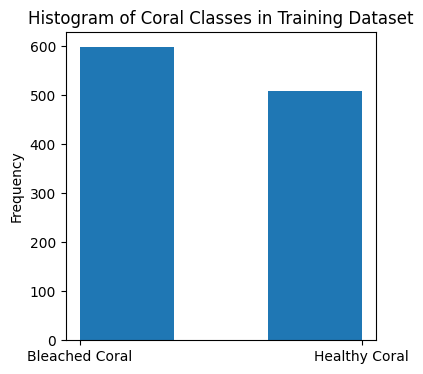

In [71]:
# Re-labeling y_train dataset values as strings for plotting
y_train_labels = np.where(y_train == 0, "Bleached Coral", "Healthy Coral")

# Histogram of training dataset coral class
plt.figure(figsize=(4,4))
plt.hist(y_train_labels, align='mid', bins = 3)
plt.title("Histogram of Coral Classes in Training Dataset")
plt.ylabel("Frequency")
plt.show()

In [75]:
# Creating list of indices for first image of each class type
index_list = []
for i in range(2): 
    indices = np.where(y_train == i)[0][:5]
    index_list.extend(indices)

# Converting dtypes to integers for plotting
images_ints = np.array(X_train*255, dtype=int)

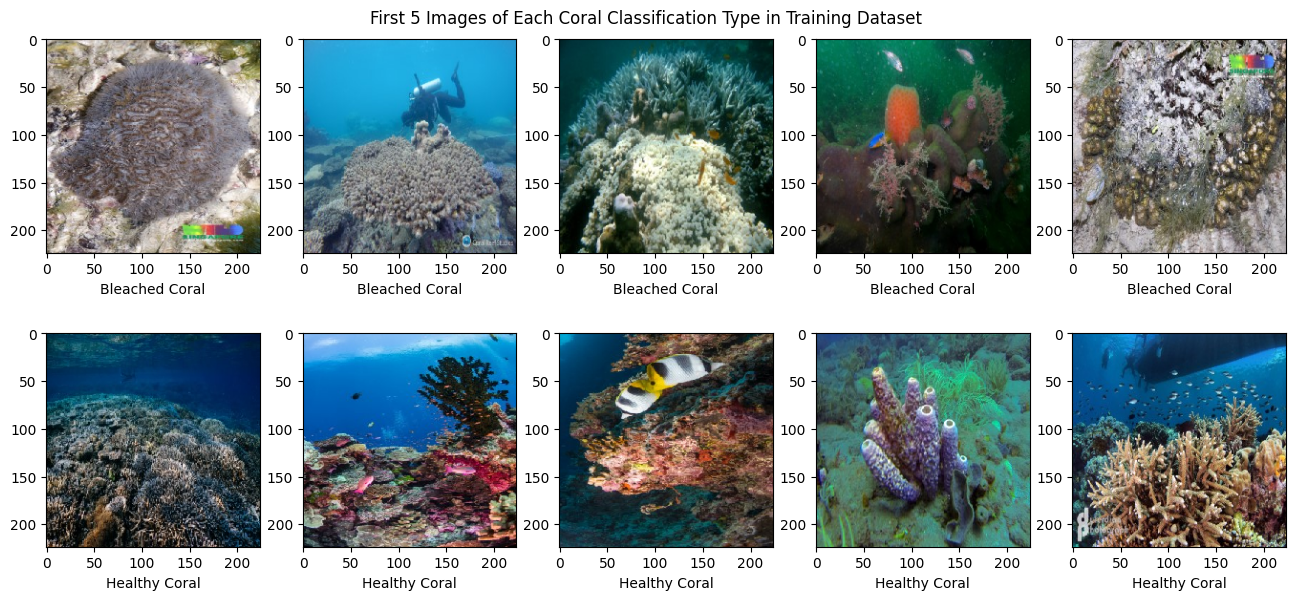

In [76]:
# Plotting first five images from each coral classification type in training data
fig, axes = plt.subplots(2, 5, figsize = (16,7))

for i, ax in enumerate(axes.flatten()):
    index = index_list[i]
    ax.imshow(images_ints[index])
    ax.set_xlabel(y_train_labels[index])

plt.suptitle("First 5 Images of Each Coral Classification Type in Training Dataset", y = 0.9)
plt.show()

In [77]:
# Reshaping X_train (for calculating mean pixel values)
X_train_reshape = X_train.reshape(1106, 50176, 3)

healthy_corals = np.where(y_train == 0)
healthy_corals = X_train_reshape[healthy_corals]
bleached_corals = np.where(y_train == 1)
bleached_corals = X_train_reshape[bleached_corals]

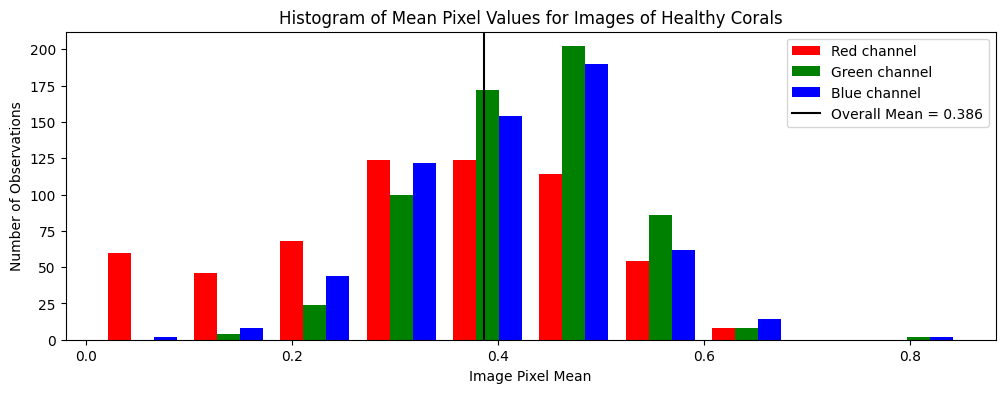

Mean of all images of healthy corals = 0.38573870062828064


In [78]:
# Calculating mean pixel values
healthy_corals_means = np.mean(healthy_corals, axis = 1)

# Plotting histogram of mean pixel values for images of healthy corals
plt.figure(figsize = (12,4))
plt.hist(healthy_corals_means, color=('red', 'green','blue'), label=('Red channel', 'Green channel', 'Blue channel'))
plt.axvline(healthy_corals.mean(), color = 'black', label = f'Overall Mean = {healthy_corals.mean():.3f}')
plt.legend()
plt.title("Histogram of Mean Pixel Values for Images of Healthy Corals")
plt.xlabel("Image Pixel Mean")
plt.ylabel("Number of Observations")
plt.show()

# Printing mean value of pixels across all images of healthy corals
print(f'Mean of all images of healthy corals = {healthy_corals.mean()}')

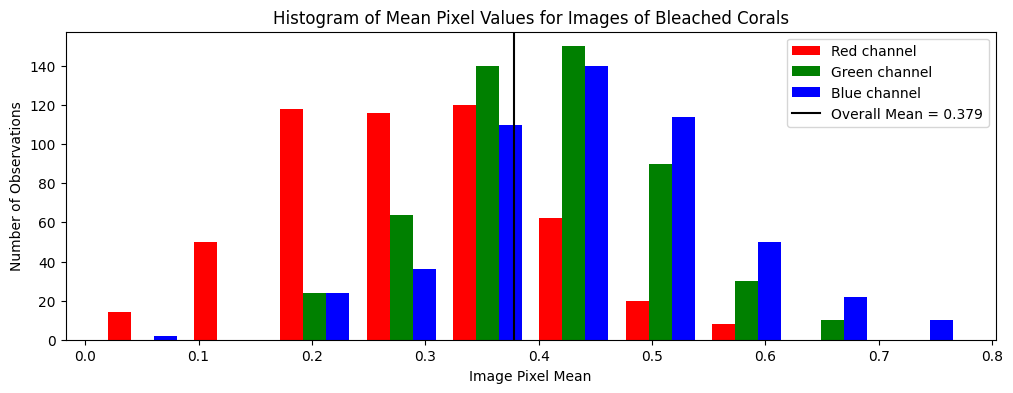

Mean of all images of bleached corals = 0.3786787986755371


In [79]:
# Calculating mean pixel values
bleached_corals_means = np.mean(bleached_corals, axis = 1)

# Plotting histogram of mean pixel values for images of bleached corals
plt.figure(figsize = (12,4))
plt.hist(bleached_corals_means, color=('red', 'green','blue') , label=('Red channel', 'Green channel', 'Blue channel'))
plt.axvline(bleached_corals.mean(), color = 'black', label = f'Overall Mean = {bleached_corals.mean():.3f}')
plt.legend()
plt.title("Histogram of Mean Pixel Values for Images of Bleached Corals")
plt.xlabel("Image Pixel Mean")
plt.ylabel("Number of Observations")
plt.show()

# Printing mean value of pixels across all images of bleached corals
print(f'Mean of all images of bleached corals = {bleached_corals.mean()}')